# EN3150 Assignment 03 — Two-Digit MNIST Classification

## Introduction / Assignment Overview

This notebook implements two-digit MNIST classification as a **100-class classification problem**. The two individual digits are combined into one target label from `00` to `99`.

# 1. Project Setup

This section prepares the Python environment, reproducibility settings, and compute device.

### 1.1 Import Libraries

The optional package-install cell is followed by the complete import block used by the assignment.

In [13]:

# Optional: install missing packages in a Jupyter/VS Code notebook.
# Run this cell only if imports below fail.

# %pip install torch torchvision pandas numpy matplotlib scikit-learn pillow tqdm


In [14]:
import os
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights,
    efficientnet_b0,
    EfficientNet_B0_Weights,
)

warnings.filterwarnings("ignore")

### 1.2 Reproducibility

A fixed random seed makes splitting and training experiments more repeatable.

In [15]:
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

### 1.3 Device Configuration

CUDA is used when available; otherwise the notebook uses the CPU.

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu126
Torchvision: 0.25.0+cu126
Device: cuda
GPU: NVIDIA GeForce RTX 2050


# 2. Dataset Overview and Data Loading

This section configures the dataset, verifies its structure, loads metadata, creates the 100-class labels, and indexes image files.

### 2.1 Configuration

Update `DATA_DIR` if the dataset is stored elsewhere.

In [17]:

# ============================================================
# CHANGE THIS PATH IF NECESSARY
# ============================================================

DATA_DIR = Path(r"C:\Users\dilha\Desktop\cnn group\archive")

# Windows example:
# DATA_DIR = Path(r"C:\Users\Sandeepa\Desktop\EN3150_Project\mnist-2-digit-dataset")

IMAGE_SIZE = 64
NUM_CLASSES = 100

BATCH_SIZE = 128 if torch.cuda.is_available() else 32
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

MAIN_EPOCHS = 20
OPTIMIZER_COMPARE_EPOCHS = 5

LEARNING_RATE = 1e-3
MOMENTUM = 0.9

# Set these to False if you want to skip the long SOTA stage initially.
RUN_MOBILENET = True
RUN_EFFICIENTNET = True
SOTA_EPOCHS = 20

OUTPUT_DIR = Path(r"C:\Users\dilha\Desktop\cnn group\outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)


DATA_DIR: C:\Users\dilha\Desktop\cnn group\archive
IMAGE_SIZE: 64
BATCH_SIZE: 128


### 2.2 Verify Dataset Structure

The notebook checks that the configured dataset exists and lists its CSV files.

In [18]:

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"DATA_DIR does not exist: {DATA_DIR.resolve()}\n"
        "Please download/extract the Kaggle MNIST 2 Digit Dataset and update DATA_DIR."
    )

print("Dataset contents:")
for item in sorted(DATA_DIR.iterdir()):
    print(" -", item.name)

print("\nCSV files found:")
for p in DATA_DIR.rglob("*.csv"):
    print(" -", p)


Dataset contents:
 - test
 - test.csv
 - train
 - train.csv

CSV files found:
 - C:\Users\dilha\Desktop\cnn group\archive\test.csv
 - C:\Users\dilha\Desktop\cnn group\archive\train.csv


### 2.3 Load CSV Files

Training and test metadata are loaded into pandas DataFrames.

In [19]:

def find_csv(filename):
    matches = list(DATA_DIR.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename} inside {DATA_DIR.resolve()}"
        )
    return matches[0]

train_csv = find_csv("train.csv")
test_csv = find_csv("test.csv")

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print("train.csv:", train_csv)
print("test.csv :", test_csv)

print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

display(train_df.head())


train.csv: C:\Users\dilha\Desktop\cnn group\archive\train.csv
test.csv : C:\Users\dilha\Desktop\cnn group\archive\test.csv

Train shape: (100000, 3)
Test shape : (50000, 3)

Train columns: ['file_name', 'label_1', 'label_2']
Test columns : ['file_name', 'label_1', 'label_2']


,file_name,label_1,label_2
0,00000_3_7.png,3,7
1,00001_0_5.png,0,5
2,00002_4_4.png,4,4
3,00003_5_9.png,5,9
4,00004_0_8.png,0,8


### 2.4 Check Required Columns

The required filename and two-digit-label columns are verified.

In [20]:

required_columns = {"file_name", "label_1", "label_2"}

for name, df in [("train.csv", train_df), ("test.csv", test_df)]:
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(
            f"{name} is missing columns: {missing}. "
            f"Found columns: {df.columns.tolist()}"
        )

print("Required columns are present.")


Required columns are present.


### 2.5 Create 100-Class Labels

The target is calculated as `10 * label_1 + label_2`, giving classes `00`–`99`.

In [21]:

def create_two_digit_label(df):
    df = df.copy()

    df["label_1"] = pd.to_numeric(df["label_1"], errors="raise").astype(int)
    df["label_2"] = pd.to_numeric(df["label_2"], errors="raise").astype(int)

    if not df["label_1"].between(0, 9).all():
        raise ValueError("label_1 contains values outside 0-9.")
    if not df["label_2"].between(0, 9).all():
        raise ValueError("label_2 contains values outside 0-9.")

    df["label"] = df["label_1"] * 10 + df["label_2"]
    return df

train_df = create_two_digit_label(train_df)
test_df = create_two_digit_label(test_df)

print("Example labels:")
display(train_df[["file_name", "label_1", "label_2", "label"]].head(15))


Example labels:


,file_name,label_1,label_2,label
0,00000_3_7.png,3,7,37
1,00001_0_5.png,0,5,5
2,00002_4_4.png,4,4,44
3,00003_5_9.png,5,9,59
4,00004_0_8.png,0,8,8
5,00005_5_6.png,5,6,56
6,00006_0_7.png,0,7,7
7,00007_0_3.png,0,3,3
8,00008_5_6.png,5,6,56
9,00009_8_8.png,8,8,88


### 2.6 Index Image Files

CSV filenames are mapped to actual image paths, and missing images cause an explicit error.

In [22]:

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}

image_lookup = {}

for path in DATA_DIR.rglob("*"):
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        image_lookup[path.name] = str(path)

print("Images indexed:", len(image_lookup))

print("\nFirst 10 image paths:")
for name, path in list(image_lookup.items())[:10]:
    print(name, "->", path)

def add_image_path(df):
    df = df.copy()
    df["image_path"] = df["file_name"].map(image_lookup)
    missing = df["image_path"].isna().sum()

    if missing:
        examples = df.loc[df["image_path"].isna(), "file_name"].head(10).tolist()
        raise FileNotFoundError(
            f"{missing} image files from the CSV were not found. "
            f"Examples: {examples}"
        )
    return df

train_df = add_image_path(train_df)
test_df = add_image_path(test_df)

print("\nAll CSV image filenames were matched successfully.")


Images indexed: 149475

First 10 image paths:
00000_3_5.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00000_3_5.png
00001_1_8.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00001_1_8.png
00002_2_6.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00002_2_6.png
00003_7_8.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00003_7_8.png
00004_2_4.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00004_2_4.png
00005_8_9.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00005_8_9.png
00006_1_3.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00006_1_3.png
00007_1_4.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00007_1_4.png
00008_6_7.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00008_6_7.png
00009_8_9.png -> C:\Users\dilha\Desktop\cnn group\archive\test\00009_8_9.png

All CSV image filenames were matched successfully.


# 3. Dataset Exploration and Preprocessing

This section explores the dataset, builds the 70/15/15 split, prepares image transformations, and creates the PyTorch input pipeline.

### 3.1 Dataset Statistics

Basic sample, image, and class counts are checked before training.

In [23]:
all_labelled = pd.concat([train_df, test_df], ignore_index=True)
print("Training samples:", len(train_df))
print("Test samples:", len(test_df))
print("Combined rows:", len(all_labelled))
print("Unique image files:", all_labelled["file_name"].nunique())
print("Unique classes:", all_labelled["label"].nunique())
print("Label range:", all_labelled["label"].min(), "to", all_labelled["label"].max())

Training samples: 100000
Test samples: 50000
Combined rows: 150000
Unique image files: 149475
Unique classes: 100
Label range: 0 to 99


### 3.2 Visualize Sample Images

The following cells display real dataset images with their combined two-digit targets.

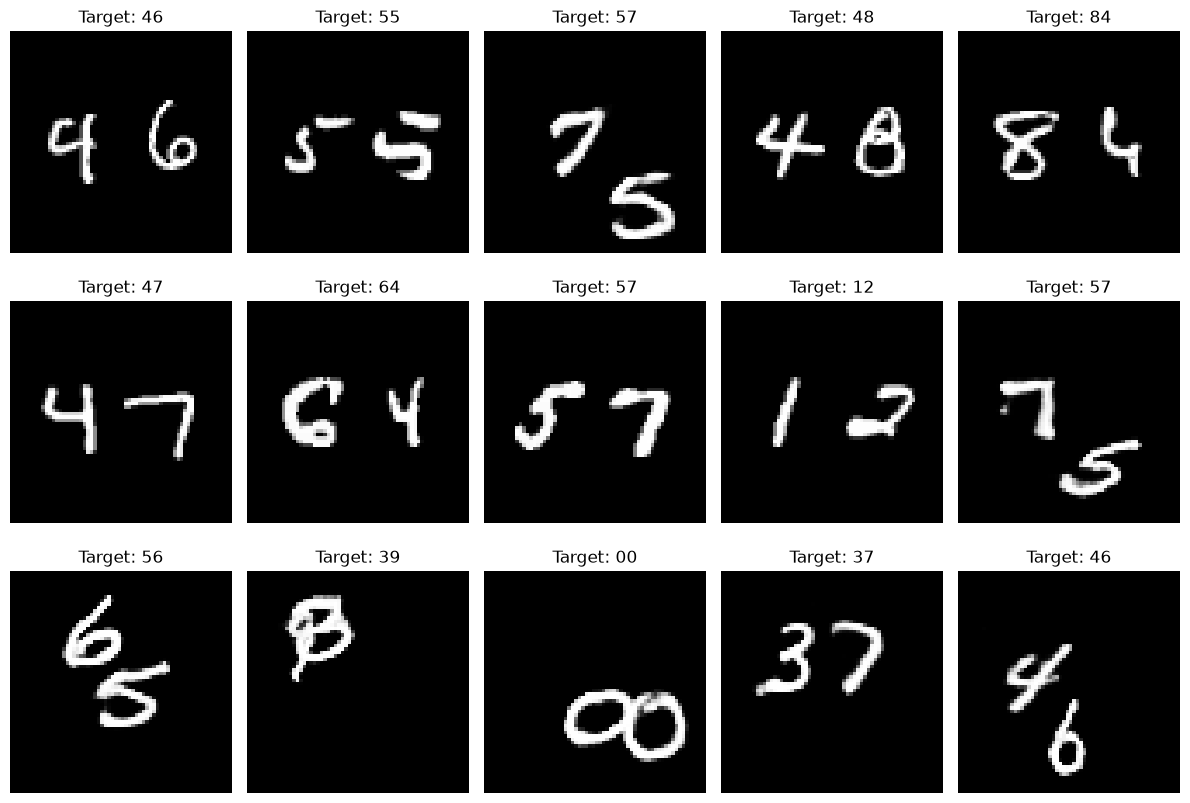

In [24]:

def show_samples(df, n=15, seed=SEED):
    sample_df = df.sample(n=min(n, len(df)), random_state=seed)

    rows = int(np.ceil(len(sample_df) / 5))
    fig, axes = plt.subplots(rows, 5, figsize=(12, 2.8 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image = Image.open(row["image_path"]).convert("L")
        ax.imshow(image, cmap="gray")
        ax.set_title(f"Target: {row['label']:02d}")
        ax.axis("off")

    for ax in axes[len(sample_df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_df, n=15)


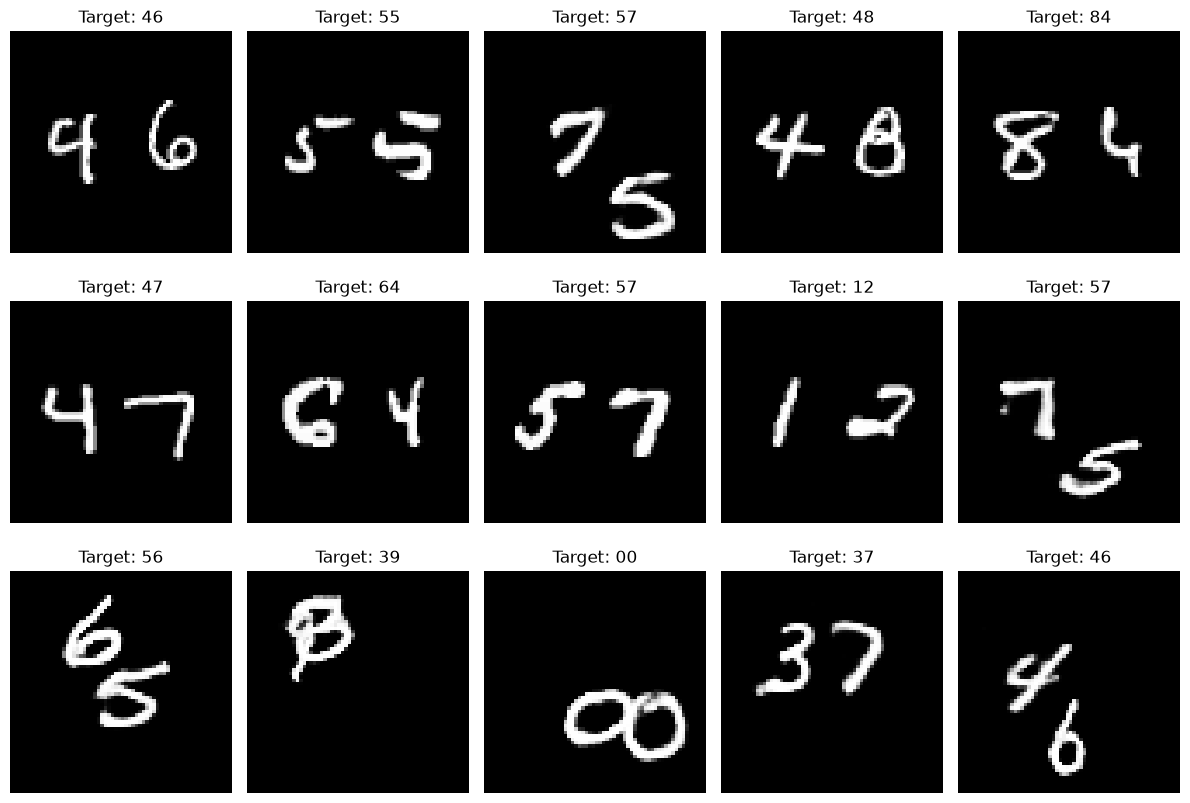

In [25]:
show_samples(train_df, n=15, seed=SEED)

### 3.3 Build 70/15/15 Train/Validation/Test Split

A stratified split creates 70% training, 15% validation, and 15% test data.

In [26]:

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df = all_df.drop_duplicates(subset=["file_name"]).reset_index(drop=True)

print("Total labelled images:", len(all_df))
print("Unique filenames:", all_df["file_name"].nunique())

train_split, temp_split = train_test_split(
    all_df,
    test_size=0.30,
    random_state=SEED,
    stratify=all_df["label"],
)

val_split, test_split = train_test_split(
    temp_split,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_split["label"],
)

train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)
test_split = test_split.reset_index(drop=True)

print("Train:", len(train_split), f"({len(train_split)/len(all_df)*100:.2f}%)")
print("Val  :", len(val_split), f"({len(val_split)/len(all_df)*100:.2f}%)")
print("Test :", len(test_split), f"({len(test_split)/len(all_df)*100:.2f}%)")


Total labelled images: 149475
Unique filenames: 149475
Train: 104632 (70.00%)
Val  : 22421 (15.00%)
Test : 22422 (15.00%)


### 3.4 Check Class Distribution

Class frequencies are inspected in the three subsets.

In [27]:

class_counts = pd.DataFrame({
    "train": train_split["label"].value_counts().sort_index(),
    "validation": val_split["label"].value_counts().sort_index(),
    "test": test_split["label"].value_counts().sort_index(),
}).fillna(0).astype(int)

display(class_counts.head(20))

print("Number of classes represented:", all_df["label"].nunique())
print("Expected number of classes:", NUM_CLASSES)


,train,validation,test
label,,,
0,1059,227,227
1,1445,310,309
2,1469,315,315
3,1495,320,321
4,1466,314,315
5,1470,315,315
6,1487,318,319
7,1466,314,314
8,1453,311,312


Number of classes represented: 100
Expected number of classes: 100


### 3.5 Image Preprocessing

Images are resized and normalized. The training transform additionally applies mild affine augmentation.

In [28]:

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=8,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


### 3.6 PyTorch Dataset

The custom Dataset loads grayscale images, applies transformations, and returns tensors with integer targets.

In [29]:
class TwoDigitDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("L")

        if self.transform:
            image = self.transform(image)

        label = int(row["label"])
        return image, label

### 3.7 DataLoaders

Training, validation, and test DataLoaders are created with the correct shuffle settings.

In [30]:
train_dataset = TwoDigitDataset(train_split, train_transform)
val_dataset = TwoDigitDataset(val_split, transform)
test_dataset = TwoDigitDataset(test_split, transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 818
Validation batches: 176
Test batches: 176


### 3.8 Check One Batch

One training batch is inspected to confirm tensor shapes and label format.

Image batch shape: torch.Size([128, 1, 64, 64])
Label batch shape: torch.Size([128])
Example labels: ['57', '15', '62', '44', '15', '05', '75', '23', '61', '16']


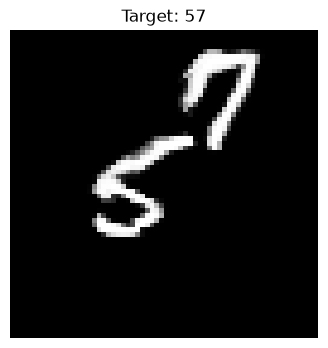

In [31]:

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Example labels:", [f"{x:02d}" for x in labels[:10].tolist()])

plt.figure(figsize=(4, 4))
plt.imshow(images[0].squeeze().numpy(), cmap="gray")
plt.title(f"Target: {labels[0].item():02d}")
plt.axis("off")
plt.show()


# 4. Model A — Standard CNN

Model A is the conventional CNN baseline.

### 4.1 Model Architecture

Three convolution/pooling blocks are followed by fully connected classification layers.

In [32]:

class StandardCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model_a = StandardCNN().to(device)
print(model_a)


StandardCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=100, bias=True)
  )
)


### 4.2 Parameter Count

The number of trainable parameters is recorded for later comparison.

In [33]:
params_a = sum(
    p.numel() for p in model_a.parameters() if p.requires_grad
)

print(f"Model A trainable parameters: {params_a:,}")


Model A trainable parameters: 560,612


### 4.3 Training Configuration

The common cross-entropy loss, optimizer factory, epoch loop, evaluation functions, plotting utility, and model-size utility are defined once and reused.

In [34]:

criterion = nn.CrossEntropyLoss()


def create_optimizer(model, name, lr=LEARNING_RATE, momentum=MOMENTUM):
    name = name.lower()

    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr)

    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr)

    if name in ["sgd_momentum", "momentum"]:
        return optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum
        )

    raise ValueError(f"Unknown optimizer: {name}")


def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            if is_training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        predictions = outputs.argmax(dim=1)
        all_predictions.extend(predictions.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_targets, all_predictions)

    return epoch_loss, epoch_accuracy


def train_model(model, train_loader, val_loader, epochs,
                optimizer_name="adam", lr=LEARNING_RATE,
                momentum=MOMENTUM, model_name="model"):

    model = model.to(device)

    optimizer = create_optimizer(
        model, optimizer_name, lr=lr, momentum=momentum
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "epoch_time": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_accuracy = -1.0

    total_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()

        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer
        )

        val_loss, val_acc = run_epoch(
            model, val_loader, criterion
        )

        epoch_time = time.perf_counter() - epoch_start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"{model_name} | Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc*100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc*100:.2f}% | "
            f"Time: {epoch_time:.1f}s"
        )

    total_time = time.perf_counter() - total_start

    model.load_state_dict(best_state)

    history["total_time"] = total_time
    history["avg_epoch_time"] = total_time / epochs
    history["best_val_accuracy"] = best_val_accuracy

    return model, history


@torch.no_grad()
def predict_model(model, loader):
    model.eval()

    all_predictions = []
    all_targets = []

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)

        outputs = model(inputs)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(targets.numpy())

    return np.array(all_targets), np.array(all_predictions)


def evaluate_model(model, loader, model_name="Model"):
    y_true, y_pred = predict_model(model, loader)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    cm = confusion_matrix(
        y_true, y_pred, labels=np.arange(NUM_CLASSES)
    )

    print(f"\n{model_name} Test Results")
    print("=" * 50)
    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}% (macro)")
    print(f"Recall   : {recall*100:.2f}% (macro)")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
    }


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Training loss")
    plt.plot(epochs, history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        np.array(history["train_accuracy"]) * 100,
        label="Training accuracy"
    )
    plt.plot(
        epochs,
        np.array(history["val_accuracy"]) * 100,
        label="Validation accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title + " — Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def save_model_size(model, filename):
    path = OUTPUT_DIR / filename
    torch.save(model.state_dict(), path)
    size_kb = path.stat().st_size / 1024
    size_mb = size_kb / 1024
    return path, size_kb, size_mb


### 4.4 Train Model A

**Actual training happens here.** Model A is trained with Adam for `MAIN_EPOCHS`; validation accuracy is tracked and the best validation state is restored.

In [ ]:

seed_everything()

model_a = StandardCNN().to(device)

model_a, history_a = train_model(
    model_a,
    train_loader,
    val_loader,
    epochs=MAIN_EPOCHS,
    optimizer_name="adam",
    lr=LEARNING_RATE,
    model_name="Model A - Standard CNN",
)

plot_history(history_a, "Model A — Standard CNN")


Model A - Standard CNN | Epoch 01/20 | Train Loss: 2.0884 | Train Acc: 45.87% | Val Loss: 0.6911 | Val Acc: 79.40% | Time: 966.7s


### 4.5 Evaluate Model A

The trained Model A is evaluated on the held-out test set.

In [ ]:

results_a = evaluate_model(
    model_a,
    test_loader,
    model_name="Model A — Standard CNN"
)



Model A — Standard CNN Test Results
Accuracy : 94.47%
Precision: 94.29% (macro)
Recall   : 94.50% (macro)


### 4.6 Confusion Matrix

The 100-class confusion matrix for Model A is displayed.

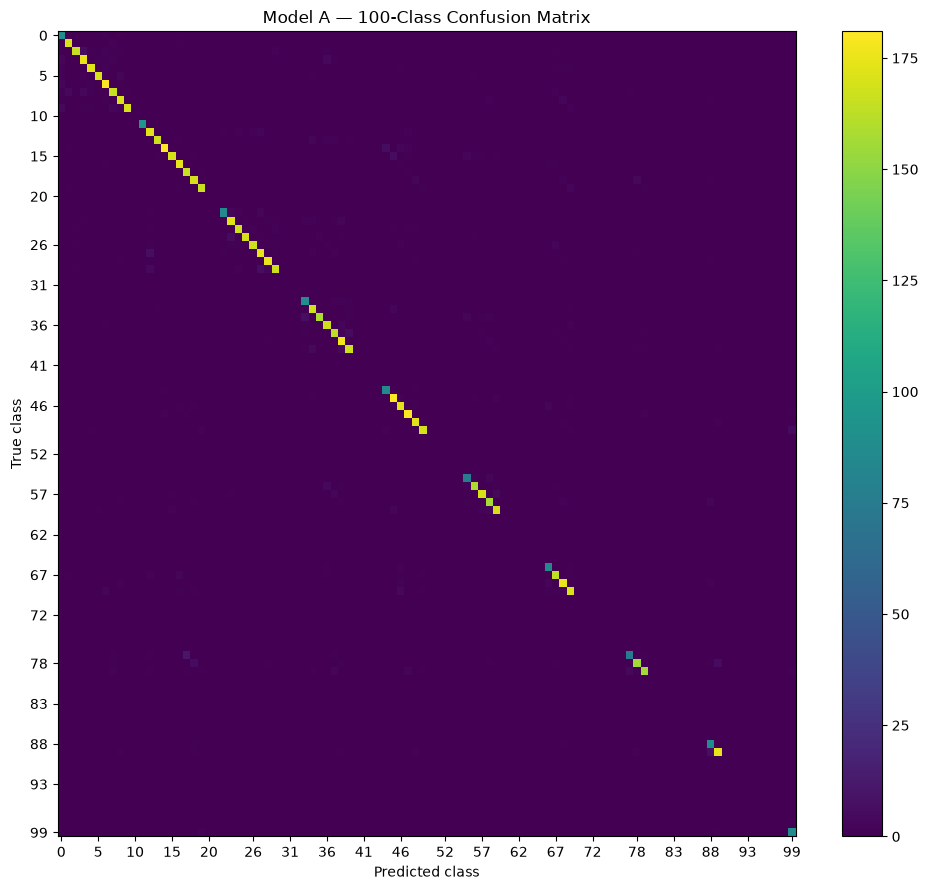

In [ ]:

def plot_confusion_matrix(cm, title, max_labels=None):
    plt.figure(figsize=(10, 9))
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.colorbar()

    if max_labels is not None and max_labels <= cm.shape[0]:
        ticks = np.linspace(0, cm.shape[0]-1, max_labels, dtype=int)
        plt.xticks(ticks)
        plt.yticks(ticks)

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    results_a["confusion_matrix"],
    "Model A — 100-Class Confusion Matrix",
    max_labels=20
)


# 5. Model B — Resource-Constrained CNN

Model B is the lightweight architecture designed to satisfy the parameter constraint.

### 5.1 Motivation

The aim is to reduce memory and parameter cost while retaining useful classification performance.

### 5.2 Depthwise-Separable Convolution

Depthwise and pointwise convolutions reduce the parameter cost compared with standard convolution.

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2

        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=in_channels,
            bias=False,
        )
        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1,
            bias=False,
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.relu(x)

### 5.3 Model Architecture

The lightweight CNN uses three depthwise-separable blocks, pooling, adaptive average pooling, and a 100-class classifier.

In [ ]:
class LightweightCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            DepthwiseSeparableConv(1, 16),
            nn.MaxPool2d(2),
            DepthwiseSeparableConv(16, 32),
            nn.MaxPool2d(2),
            DepthwiseSeparableConv(32, 64),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model_b = LightweightCNN().to(device)
print(model_b)

LightweightCNN(
  (features): Sequential(
    (0): DepthwiseSeparableConv(
      (depthwise): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (pointwise): Conv2d(1, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): DepthwiseSeparableConv(
      (depthwise): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
      (pointwise): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): DepthwiseSeparableConv(
      (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 

### 5.4 Parameter Count Verification (<100,000)

The assignment constraint is checked explicitly.

In [ ]:

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_all_parameters(model):
    return sum(p.numel() for p in model.parameters())

params_a = count_parameters(model_a)
params_b = count_parameters(model_b)

print(f"Model A trainable parameters: {params_a:,}")
print(f"Model B trainable parameters: {params_b:,}")

assert params_b < 100_000, (
    f"Model B has {params_b:,} parameters, which violates the <100,000 requirement."
)

print("\nPASS: Model B is below 100,000 trainable parameters.")


Model A trainable parameters: 560,612
Model B trainable parameters: 9,741

PASS: Model B is below 100,000 trainable parameters.


### 5.5 Train Model B

**Actual training happens here.** Model B is trained with the same train/validation data pipeline and the same general training procedure as Model A.

Model B - Lightweight CNN | Epoch 01/20 | Train Loss: 3.8681 | Train Acc: 5.77% | Val Loss: 3.6792 | Val Acc: 6.70% | Time: 47.2s
Model B - Lightweight CNN | Epoch 02/20 | Train Loss: 3.3076 | Train Acc: 16.01% | Val Loss: 4.3635 | Val Acc: 4.67% | Time: 47.3s
Model B - Lightweight CNN | Epoch 03/20 | Train Loss: 2.7511 | Train Acc: 28.83% | Val Loss: 10.1989 | Val Acc: 2.95% | Time: 47.7s
Model B - Lightweight CNN | Epoch 04/20 | Train Loss: 2.2765 | Train Acc: 42.07% | Val Loss: 3.0491 | Val Acc: 14.58% | Time: 46.8s
Model B - Lightweight CNN | Epoch 05/20 | Train Loss: 1.9073 | Train Acc: 51.27% | Val Loss: 8.4406 | Val Acc: 6.50% | Time: 48.5s
Model B - Lightweight CNN | Epoch 06/20 | Train Loss: 1.6542 | Train Acc: 57.39% | Val Loss: 12.9563 | Val Acc: 2.13% | Time: 46.6s
Model B - Lightweight CNN | Epoch 07/20 | Train Loss: 1.4817 | Train Acc: 61.40% | Val Loss: 3.2708 | Val Acc: 17.61% | Time: 44.9s
Model B - Lightweight CNN | Epoch 08/20 | Train Loss: 1.3494 | Train Acc: 64.13%

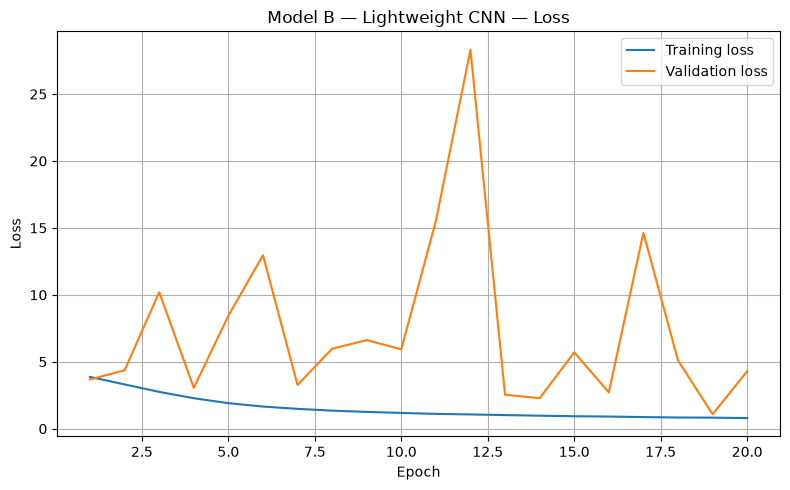

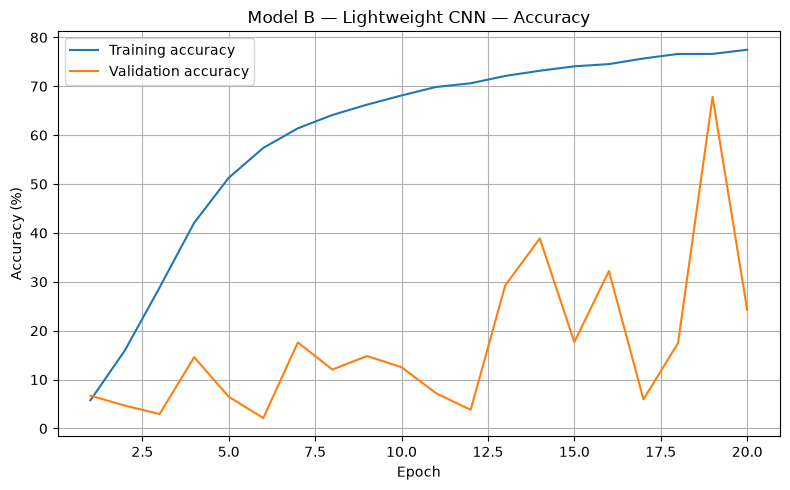

In [ ]:

seed_everything()

model_b = LightweightCNN().to(device)

model_b, history_b = train_model(
    model_b,
    train_loader,
    val_loader,
    epochs=MAIN_EPOCHS,
    optimizer_name="adam",
    lr=LEARNING_RATE,
    model_name="Model B - Lightweight CNN",
)

plot_history(history_b, "Model B — Lightweight CNN")


### 5.6 Evaluate Model B

The trained lightweight model is evaluated on the held-out test set.

In [ ]:

results_b = evaluate_model(
    model_b,
    test_loader,
    model_name="Model B — Lightweight CNN"
)



Model B — Lightweight CNN Test Results
Accuracy : 68.39%
Precision: 74.80% (macro)
Recall   : 69.43% (macro)


### 5.7 Confusion Matrix

The Model B confusion matrix is displayed.

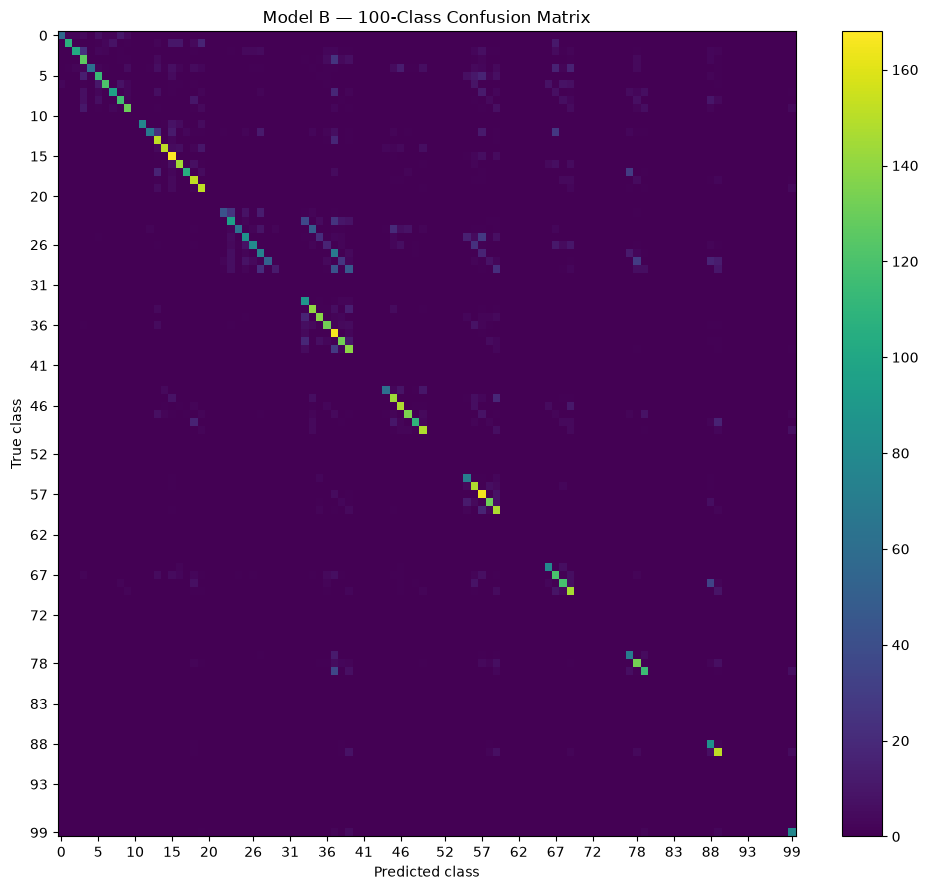

In [ ]:

plot_confusion_matrix(
    results_b["confusion_matrix"],
    "Model B — 100-Class Confusion Matrix",
    max_labels=20
)


# 6. Optimizer Comparison

Model B is compared using Adam, SGD, and SGD with momentum.

### 6.1 Adam

Adam uses the learning rate selected in the experiment code.

### 6.2 SGD

Plain SGD provides a simpler optimization baseline.

### 6.3 SGD + Momentum

Momentum is included to evaluate whether accumulated update direction improves optimization.

In [ ]:

optimizer_results = []

for optimizer_name in ["sgd", "sgd_momentum", "adam"]:
    print("\n" + "=" * 70)
    print("Optimizer:", optimizer_name)

    seed_everything()

    temp_model = LightweightCNN().to(device)

    if optimizer_name == "sgd":
        lr = 0.01
    elif optimizer_name == "sgd_momentum":
        lr = 0.01
    else:
        lr = 0.001

    temp_model, temp_history = train_model(
        temp_model,
        train_loader,
        val_loader,
        epochs=OPTIMIZER_COMPARE_EPOCHS,
        optimizer_name=optimizer_name,
        lr=lr,
        momentum=MOMENTUM,
        model_name=f"Model B - {optimizer_name}",
    )

    optimizer_results.append({
        "Optimizer": optimizer_name,
        "Learning Rate": lr,
        "Momentum": MOMENTUM if optimizer_name == "sgd_momentum" else 0.0,
        "Best Validation Accuracy (%)":
            temp_history["best_val_accuracy"] * 100,
        "Average Epoch Time (s)":
            temp_history["avg_epoch_time"],
    })

optimizer_results_df = pd.DataFrame(optimizer_results)
display(optimizer_results_df)



Optimizer: sgd
Model B - sgd | Epoch 01/5 | Train Loss: 4.3950 | Train Acc: 1.70% | Val Loss: 4.2121 | Val Acc: 2.16% | Time: 46.2s
Model B - sgd | Epoch 02/5 | Train Loss: 4.1294 | Train Acc: 2.46% | Val Loss: 4.0736 | Val Acc: 3.09% | Time: 45.6s
Model B - sgd | Epoch 03/5 | Train Loss: 4.0414 | Train Acc: 3.02% | Val Loss: 4.0147 | Val Acc: 4.31% | Time: 46.6s
Model B - sgd | Epoch 04/5 | Train Loss: 3.9981 | Train Acc: 3.90% | Val Loss: 3.9802 | Val Acc: 4.51% | Time: 45.3s
Model B - sgd | Epoch 05/5 | Train Loss: 3.9690 | Train Acc: 4.46% | Val Loss: 3.9520 | Val Acc: 5.88% | Time: 47.9s

Optimizer: sgd_momentum
Model B - sgd_momentum | Epoch 01/5 | Train Loss: 4.0206 | Train Acc: 3.74% | Val Loss: 3.8086 | Val Acc: 5.57% | Time: 47.1s
Model B - sgd_momentum | Epoch 02/5 | Train Loss: 3.6303 | Train Acc: 8.65% | Val Loss: 3.4542 | Val Acc: 11.10% | Time: 46.7s
Model B - sgd_momentum | Epoch 03/5 | Train Loss: 3.2693 | Train Acc: 14.69% | Val Loss: 3.0318 | Val Acc: 19.85% | Time:

,Optimizer,Learning Rate,Momentum,Best Validation Accuracy (%),Average Epoch Time (s)
0,sgd,0.010,0.0,5.877115,46.325199
1,sgd_momentum,0.010,0.9,19.846394,46.670457
2,adam,0.001,0.0,10.307213,46.208034


### 6.4 Comparison Results

Validation accuracy and average epoch time are reported for the tested optimizers.

In [ ]:
display(optimizer_results_df)

,Optimizer,Learning Rate,Momentum,Best Validation Accuracy (%),Average Epoch Time (s)
0,sgd,0.010,0.0,5.877115,46.325199
1,sgd_momentum,0.010,0.9,19.846394,46.670457
2,adam,0.001,0.0,10.307213,46.208034


### 6.5 Interpretation

Compare validation accuracy and training time together rather than selecting an optimizer using only one metric.

# 7. Model Size and Computational Cost

Model A and Model B are compared by storage size, training time, and parameter count.

### 7.1 Model Size

The trained state dictionaries are saved and their sizes are measured.

In [ ]:
path_a, size_a_kb, size_a_mb = save_model_size(
    model_a, "model_a_standard_cnn.pth"
)
path_b, size_b_kb, size_b_mb = save_model_size(
    model_b, "model_b_lightweight_cnn.pth"
)

print(f"Model A size: {size_a_kb:.2f} KB ({size_a_mb:.4f} MB)")
print(f"Model B size: {size_b_kb:.2f} KB ({size_b_mb:.4f} MB)")

Model A size: 2194.52 KB (2.1431 MB)
Model B size: 47.73 KB (0.0466 MB)


### 7.2 Training Time

The average epoch time recorded during training is compared.

In [ ]:
print(f"Model A average training time/epoch: {history_a['avg_epoch_time']:.2f} s")
print(f"Model B average training time/epoch: {history_b['avg_epoch_time']:.2f} s")

Model A average training time/epoch: 46.42 s
Model B average training time/epoch: 46.40 s


### 7.3 Parameter Count Comparison

The custom CNNs are combined into one table containing parameters, size, training time, and predictive performance.

In [ ]:
custom_results = pd.DataFrame([
    {
        "Model": "Model A - Standard CNN",
        "Trainable Parameters": count_parameters(model_a),
        "Model Size (KB)": size_a_kb,
        "Model Size (MB)": size_a_mb,
        "Training Time / Epoch (s)": history_a["avg_epoch_time"],
        "Test Accuracy (%)": results_a["accuracy"] * 100,
        "Precision (%)": results_a["precision"] * 100,
        "Recall (%)": results_a["recall"] * 100,
    },
    {
        "Model": "Model B - Lightweight CNN",
        "Trainable Parameters": count_parameters(model_b),
        "Model Size (KB)": size_b_kb,
        "Model Size (MB)": size_b_mb,
        "Training Time / Epoch (s)": history_b["avg_epoch_time"],
        "Test Accuracy (%)": results_b["accuracy"] * 100,
        "Precision (%)": results_b["precision"] * 100,
        "Recall (%)": results_b["recall"] * 100,
    }
])
display(custom_results)

,Model,Trainable Parameters,Model Size (KB),Model Size (MB),Training Time / Epoch (s),Test Accuracy (%),Precision (%),Recall (%)
0,Model A - Standard CNN,560612,2194.520508,2.143086,46.416444,94.468559,94.287515,94.504659
1,Model B - Lightweight CNN,9741,47.732422,0.046614,46.397111,68.391764,74.795609,69.433858


# 8. Transfer Learning

Pretrained MobileNetV2 and EfficientNet-B0 are used as additional reference models. Grayscale images are replicated to three channels for pretrained torchvision architectures.

### 8.1 MobileNetV2

The RGB-style preprocessing and transfer-learning DataLoaders are created here.

In [ ]:

USE_PRETRAINED = True

sota_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

sota_train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=8,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

sota_train_dataset = TwoDigitDataset(train_split, sota_train_transform)
sota_val_dataset = TwoDigitDataset(val_split, sota_transform)
sota_test_dataset = TwoDigitDataset(test_split, sota_transform)

sota_train_loader = DataLoader(
    sota_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

sota_val_loader = DataLoader(
    sota_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

sota_test_loader = DataLoader(
    sota_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("SOTA dataloaders ready.")


SOTA dataloaders ready.


### 8.2 Fine-tuning MobileNetV2

MobileNetV2 is adapted to 100 output classes and fine-tuned when `RUN_MOBILENET=True`.

In [ ]:

def build_mobilenet(num_classes=NUM_CLASSES, pretrained=True):
    if pretrained:
        model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    else:
        model = mobilenet_v2(weights=None)

    model.classifier[1] = nn.Linear(
        model.last_channel,
        num_classes
    )

    return model


def build_efficientnet(num_classes=NUM_CLASSES, pretrained=True):
    if pretrained:
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    else:
        model = efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Linear(
        in_features,
        num_classes
    )

    return model


mobilenet_model = build_mobilenet(pretrained=USE_PRETRAINED).to(device)
efficientnet_model = build_efficientnet(pretrained=USE_PRETRAINED).to(device)

print("MobileNetV2 parameters:", f"{count_all_parameters(mobilenet_model):,}")
print("EfficientNet-B0 parameters:", f"{count_all_parameters(efficientnet_model):,}")


MobileNetV2 parameters: 2,351,972
EfficientNet-B0 parameters: 4,135,648


MobileNetV2 | Epoch 01/20 | Train Loss: 3.6199 | Train Acc: 11.57% | Val Loss: 2.5410 | Val Acc: 30.22% | Time: 69.3s
MobileNetV2 | Epoch 02/20 | Train Loss: 1.9383 | Train Acc: 44.36% | Val Loss: 1.1354 | Val Acc: 66.83% | Time: 68.5s
MobileNetV2 | Epoch 03/20 | Train Loss: 1.0114 | Train Acc: 69.76% | Val Loss: 0.5795 | Val Acc: 83.33% | Time: 70.8s
MobileNetV2 | Epoch 04/20 | Train Loss: 0.6355 | Train Acc: 80.93% | Val Loss: 0.3846 | Val Acc: 88.47% | Time: 68.3s
MobileNetV2 | Epoch 05/20 | Train Loss: 0.4773 | Train Acc: 85.54% | Val Loss: 0.2841 | Val Acc: 91.17% | Time: 77.4s
MobileNetV2 | Epoch 06/20 | Train Loss: 0.3840 | Train Acc: 88.24% | Val Loss: 0.2392 | Val Acc: 92.36% | Time: 75.2s
MobileNetV2 | Epoch 07/20 | Train Loss: 0.3196 | Train Acc: 90.07% | Val Loss: 0.2048 | Val Acc: 93.34% | Time: 114.6s
MobileNetV2 | Epoch 08/20 | Train Loss: 0.2791 | Train Acc: 91.34% | Val Loss: 0.1801 | Val Acc: 94.35% | Time: 92.6s
MobileNetV2 | Epoch 09/20 | Train Loss: 0.2461 | Train 

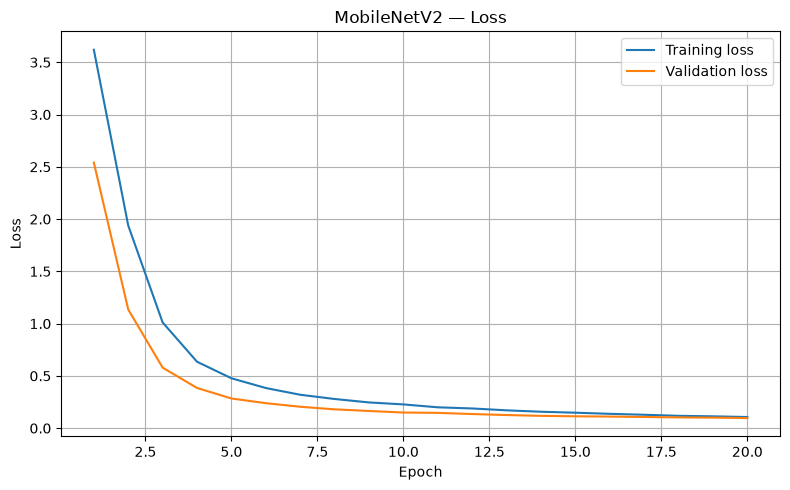

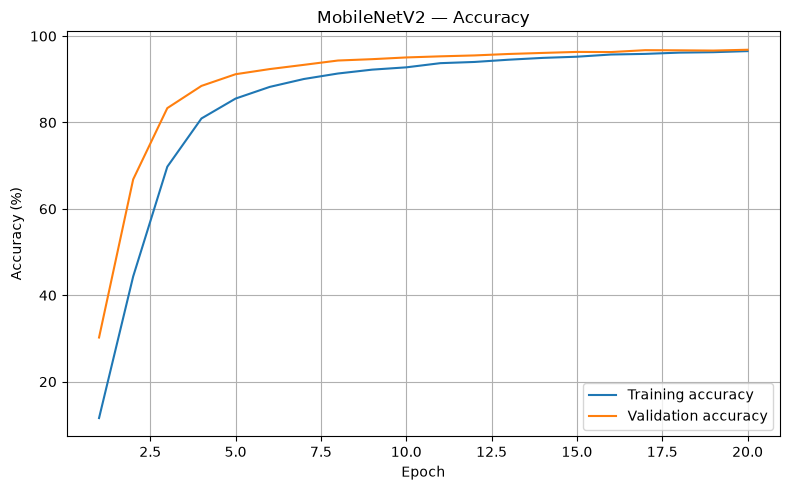


MobileNetV2 Test Results
Accuracy : 96.79%
Precision: 96.70% (macro)
Recall   : 96.79% (macro)


In [ ]:

mobilenet_history = None
mobilenet_results = None
mobilenet_size_kb = None
mobilenet_size_mb = None

if RUN_MOBILENET:
    seed_everything()

    mobilenet_model, mobilenet_history = train_model(
        mobilenet_model,
        sota_train_loader,
        sota_val_loader,
        epochs=SOTA_EPOCHS,
        optimizer_name="adam",
        lr=1e-4 if USE_PRETRAINED else 1e-3,
        model_name="MobileNetV2",
    )

    plot_history(mobilenet_history, "MobileNetV2")

    mobilenet_results = evaluate_model(
        mobilenet_model,
        sota_test_loader,
        model_name="MobileNetV2"
    )

    _, mobilenet_size_kb, mobilenet_size_mb = save_model_size(
        mobilenet_model,
        "mobilenet_v2_two_digit.pth"
    )
else:
    print("MobileNetV2 stage skipped. Set RUN_MOBILENET=True to run it.")


### 8.3 Evaluation

The MobileNetV2 test metrics and model size are stored for the final comparison. When the run flag is disabled, no fake result is created.

### 8.4 EfficientNet-B0

The EfficientNet-B0 classifier is adapted to the same 100-class task.

In [ ]:
# build_efficientnet was defined together with build_mobilenet above.
efficientnet_model = build_efficientnet(
    pretrained=USE_PRETRAINED
).to(device)

print(
    "EfficientNet-B0 parameters:",
    f"{count_all_parameters(efficientnet_model):,}"
)

EfficientNet-B0 parameters: 4,135,648


### 8.5 Fine-tuning EfficientNet-B0

EfficientNet-B0 is fine-tuned using the same training helper when `RUN_EFFICIENTNET=True`.

EfficientNet-B0 | Epoch 01/20 | Train Loss: 3.5831 | Train Acc: 12.68% | Val Loss: 2.2141 | Val Acc: 38.70% | Time: 80.4s
EfficientNet-B0 | Epoch 02/20 | Train Loss: 1.5272 | Train Acc: 56.82% | Val Loss: 0.5982 | Val Acc: 83.69% | Time: 79.7s
EfficientNet-B0 | Epoch 03/20 | Train Loss: 0.6670 | Train Acc: 80.55% | Val Loss: 0.3689 | Val Acc: 88.54% | Time: 79.7s
EfficientNet-B0 | Epoch 04/20 | Train Loss: 0.4272 | Train Acc: 87.26% | Val Loss: 0.2155 | Val Acc: 93.41% | Time: 79.6s
EfficientNet-B0 | Epoch 05/20 | Train Loss: 0.3263 | Train Acc: 90.32% | Val Loss: 0.1672 | Val Acc: 94.74% | Time: 79.5s
EfficientNet-B0 | Epoch 06/20 | Train Loss: 0.2695 | Train Acc: 91.68% | Val Loss: 0.1461 | Val Acc: 95.12% | Time: 79.7s
EfficientNet-B0 | Epoch 07/20 | Train Loss: 0.2241 | Train Acc: 92.99% | Val Loss: 0.1173 | Val Acc: 96.13% | Time: 79.3s
EfficientNet-B0 | Epoch 08/20 | Train Loss: 0.1973 | Train Acc: 93.83% | Val Loss: 0.1241 | Val Acc: 95.93% | Time: 79.6s
EfficientNet-B0 | Epoch 

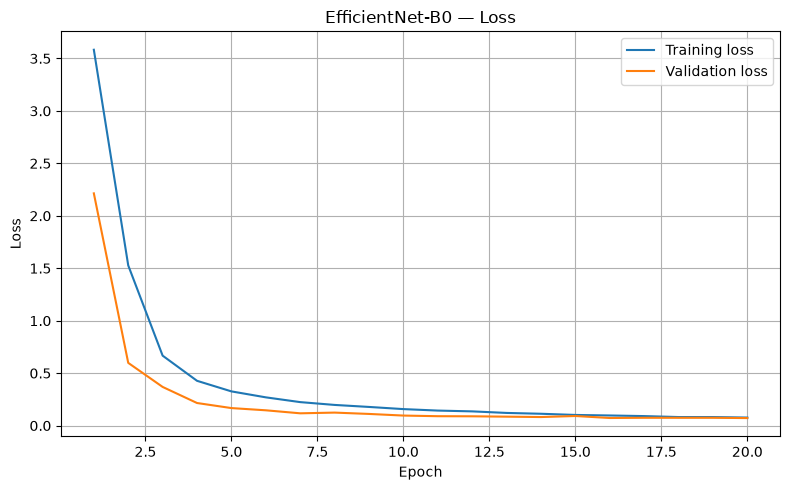

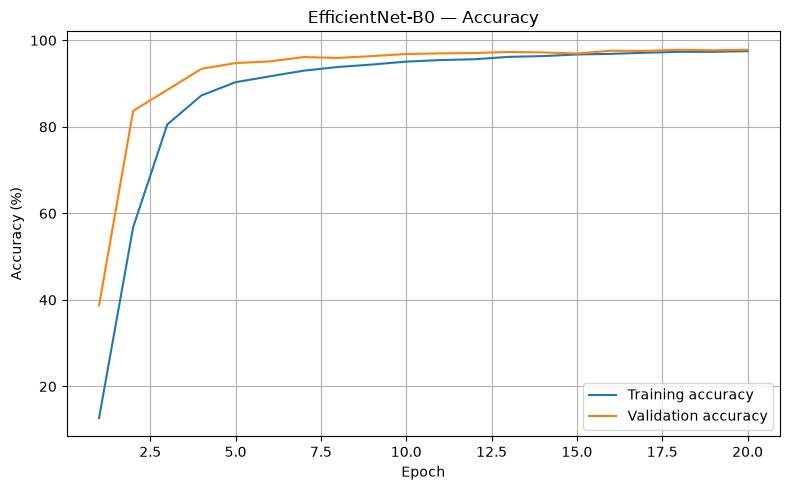


EfficientNet-B0 Test Results
Accuracy : 97.48%
Precision: 97.33% (macro)
Recall   : 97.49% (macro)


In [ ]:

efficientnet_history = None
efficientnet_results = None
efficientnet_size_kb = None
efficientnet_size_mb = None

if RUN_EFFICIENTNET:
    seed_everything()

    efficientnet_model, efficientnet_history = train_model(
        efficientnet_model,
        sota_train_loader,
        sota_val_loader,
        epochs=SOTA_EPOCHS,
        optimizer_name="adam",
        lr=1e-4 if USE_PRETRAINED else 1e-3,
        model_name="EfficientNet-B0",
    )

    plot_history(efficientnet_history, "EfficientNet-B0")

    efficientnet_results = evaluate_model(
        efficientnet_model,
        sota_test_loader,
        model_name="EfficientNet-B0"
    )

    _, efficientnet_size_kb, efficientnet_size_mb = save_model_size(
        efficientnet_model,
        "efficientnet_b0_two_digit.pth"
    )
else:
    print("EfficientNet-B0 stage skipped. Set RUN_EFFICIENTNET=True to run it.")


### 8.6 Evaluation

The EfficientNet-B0 metrics and saved size are retained for the final comparison.

# 9. Final Model Comparison

All available models are combined into a single final comparison table.

### 9.1 Accuracy Comparison

In [ ]:

comparison_rows = []

comparison_rows.append({
    "Model": "Model A - Standard CNN",
    "Parameters": count_parameters(model_a),
    "Size (KB)": size_a_kb,
    "Size (MB)": size_a_mb,
    "Time/Epoch (s)": history_a["avg_epoch_time"],
    "Accuracy (%)": results_a["accuracy"] * 100,
    "Precision (%)": results_a["precision"] * 100,
    "Recall (%)": results_a["recall"] * 100,
})

comparison_rows.append({
    "Model": "Model B - Lightweight CNN",
    "Parameters": count_parameters(model_b),
    "Size (KB)": size_b_kb,
    "Size (MB)": size_b_mb,
    "Time/Epoch (s)": history_b["avg_epoch_time"],
    "Accuracy (%)": results_b["accuracy"] * 100,
    "Precision (%)": results_b["precision"] * 100,
    "Recall (%)": results_b["recall"] * 100,
})

if mobilenet_results is not None:
    comparison_rows.append({
        "Model": "MobileNetV2",
        "Parameters": count_all_parameters(mobilenet_model),
        "Size (KB)": mobilenet_size_kb,
        "Size (MB)": mobilenet_size_mb,
        "Time/Epoch (s)": mobilenet_history["avg_epoch_time"],
        "Accuracy (%)": mobilenet_results["accuracy"] * 100,
        "Precision (%)": mobilenet_results["precision"] * 100,
        "Recall (%)": mobilenet_results["recall"] * 100,
    })

if efficientnet_results is not None:
    comparison_rows.append({
        "Model": "EfficientNet-B0",
        "Parameters": count_all_parameters(efficientnet_model),
        "Size (KB)": efficientnet_size_kb,
        "Size (MB)": efficientnet_size_mb,
        "Time/Epoch (s)": efficientnet_history["avg_epoch_time"],
        "Accuracy (%)": efficientnet_results["accuracy"] * 100,
        "Precision (%)": efficientnet_results["precision"] * 100,
        "Recall (%)": efficientnet_results["recall"] * 100,
    })

final_comparison = pd.DataFrame(comparison_rows)

display(
    final_comparison.style.format({
        "Parameters": "{:,.0f}",
        "Size (KB)": "{:.2f}",
        "Size (MB)": "{:.4f}",
        "Time/Epoch (s)": "{:.2f}",
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
    })
)

final_comparison.to_csv(
    OUTPUT_DIR / "final_model_comparison.csv",
    index=False
)


,Model,Parameters,Size (KB),Size (MB),Time/Epoch (s),Accuracy (%),Precision (%),Recall (%)
0,Model A - Standard CNN,"560,612",2194.52,2.1431,46.42,94.47,94.29,94.50
1,Model B - Lightweight CNN,"9,741",47.73,0.0466,46.40,68.39,74.80,69.43
2,MobileNetV2,"2,351,972",9431.07,9.2100,82.52,96.79,96.70,96.79
3,EfficientNet-B0,"4,135,648",16452.98,16.0674,79.61,97.48,97.33,97.49


### 9.2 Precision and Recall

In [ ]:
display(
    final_comparison[
        ["Model", "Accuracy (%)", "Precision (%)", "Recall (%)"]
    ]
)

,Model,Accuracy (%),Precision (%),Recall (%)
0,Model A - Standard CNN,94.468559,94.287515,94.504659
1,Model B - Lightweight CNN,68.391764,74.795609,69.433858
2,MobileNetV2,96.794658,96.695923,96.788311
3,EfficientNet-B0,97.484697,97.330880,97.490327


### 9.3 Model Size

In [ ]:
display(
    final_comparison[
        ["Model", "Parameters", "Size (KB)", "Size (MB)"]
    ]
)

,Model,Parameters,Size (KB),Size (MB)
0,Model A - Standard CNN,560612,2194.520508,2.143086
1,Model B - Lightweight CNN,9741,47.732422,0.046614
2,MobileNetV2,2351972,9431.073242,9.210032
3,EfficientNet-B0,4135648,16452.979492,16.067363


### 9.4 Computational Cost

In [ ]:
display(
    final_comparison[
        ["Model", "Parameters", "Time/Epoch (s)"]
    ]
)

,Model,Parameters,Time/Epoch (s)
0,Model A - Standard CNN,560612,46.416444
1,Model B - Lightweight CNN,9741,46.397111
2,MobileNetV2,2351972,82.521961
3,EfficientNet-B0,4135648,79.609777


### 9.5 Accuracy vs Model Size

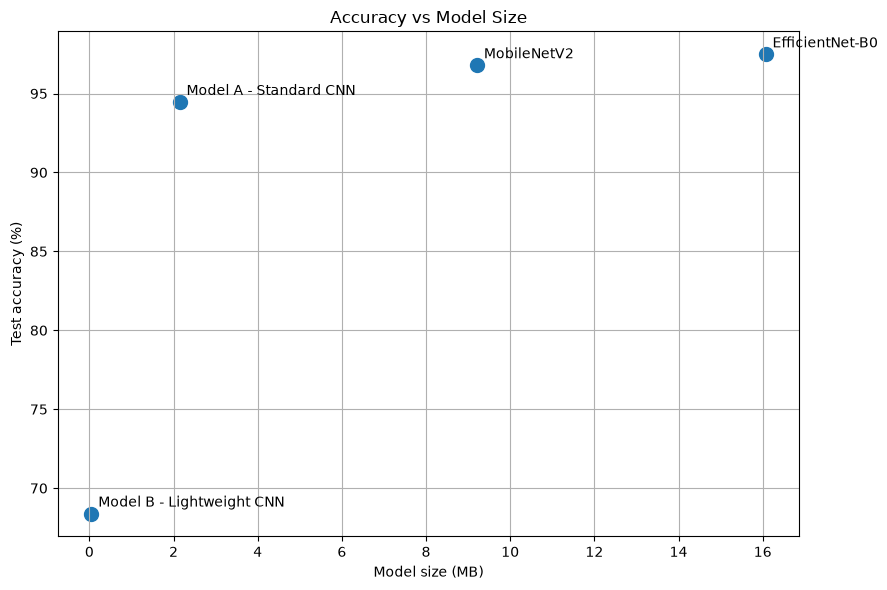

In [ ]:

plt.figure(figsize=(9, 6))

plt.scatter(
    final_comparison["Size (MB)"],
    final_comparison["Accuracy (%)"],
    s=100
)

for _, row in final_comparison.iterrows():
    plt.annotate(
        row["Model"],
        (row["Size (MB)"], row["Accuracy (%)"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Model size (MB)")
plt.ylabel("Test accuracy (%)")
plt.title("Accuracy vs Model Size")
plt.grid(True)
plt.tight_layout()
plt.show()


### Final Report Summary

The best-accuracy and smallest-parameter models are identified for discussion.

In [ ]:

best_accuracy_row = final_comparison.loc[
    final_comparison["Accuracy (%)"].idxmax()
]

smallest_model_row = final_comparison.loc[
    final_comparison["Parameters"].idxmin()
]

print("REPORT SUMMARY")
print("=" * 70)

print(
    f"Highest test accuracy: {best_accuracy_row['Model']} "
    f"({best_accuracy_row['Accuracy (%)']:.2f}%)"
)

print(
    f"Smallest model by parameter count: "
    f"{smallest_model_row['Model']} "
    f"({smallest_model_row['Parameters']:,} parameters)"
)

print(
    f"Model B parameters: {count_parameters(model_b):,} "
    f"(must be <100,000)"
)

print(
    f"Model A average training time/epoch: "
    f"{history_a['avg_epoch_time']:.2f} s"
)

print(
    f"Model B average training time/epoch: "
    f"{history_b['avg_epoch_time']:.2f} s"
)


REPORT SUMMARY
Highest test accuracy: EfficientNet-B0 (97.48%)
Smallest model by parameter count: Model B - Lightweight CNN (9,741 parameters)
Model B parameters: 9,741 (must be <100,000)
Model A average training time/epoch: 46.42 s
Model B average training time/epoch: 46.40 s


# 10. Error Analysis

Confusion matrices are analyzed to find the most frequent incorrect predictions.

### 10.1 Most Common Classification Confusions

In [ ]:

def top_confusions(cm, top_n=20):
    cm_copy = cm.copy()
    np.fill_diagonal(cm_copy, 0)

    flat_indices = np.argsort(cm_copy.ravel())[::-1]

    rows = []
    used = 0

    for flat_idx in flat_indices:
        true_class, predicted_class = np.unravel_index(
            flat_idx, cm_copy.shape
        )

        count = cm_copy[true_class, predicted_class]

        if count <= 0:
            break

        rows.append({
            "True": f"{true_class:02d}",
            "Predicted": f"{predicted_class:02d}",
            "Count": int(count),
        })

        used += 1

        if used >= top_n:
            break

    return pd.DataFrame(rows)

print("Model A top confusions:")
display(top_confusions(results_a["confusion_matrix"]))

print("Model B top confusions:")
display(top_confusions(results_b["confusion_matrix"]))


Model A top confusions:


,True,Predicted,Count
0,77,17,11
1,35,33,7
2,29,27,7
3,89,88,7
4,27,12,7
5,15,45,6
6,02,03,6
7,14,44,6
8,78,18,5
9,37,39,5


Model B top confusions:


,True,Predicted,Count
0,27,37,68
1,24,34,49
2,29,39,47
3,29,37,43
4,23,33,37
5,79,37,36
6,68,88,34
7,17,77,29
8,28,78,29
9,25,57,28


### 10.2 Interpretation

Frequent confusion pairs can reveal visually similar two-digit classes and limitations of the learned representation.

# 11. Results Export

The main result tables and trained-weight files are made available for the final report.

### 11.1 Save Figures

Figures are generated beside their corresponding experiments, so they remain associated with the relevant analysis.

### 11.2 Save CSV Results

The main result tables are saved as CSV files.

In [ ]:
custom_results.to_csv(
    OUTPUT_DIR / "custom_model_results.csv",
    index=False
)

final_comparison.to_csv(
    OUTPUT_DIR / "final_model_comparison.csv",
    index=False
)

print("CSV results saved.")

CSV results saved.


### 11.3 Save Model Weights

Model A and Model B weights are saved during Section 7. Transfer-learning weights are saved automatically when those experiments are enabled.

In [ ]:
print("Output files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"{path.name:45s} {path.stat().st_size/1024:.2f} KB")

Output files:
custom_model_results.csv                      0.39 KB
efficientnet_b0_two_digit.pth                 16452.98 KB
final_model_comparison.csv                    0.61 KB
mobilenet_v2_two_digit.pth                    9431.07 KB
model_a_standard_cnn.pth                      2194.52 KB
model_b_lightweight_cnn.pth                   47.73 KB
